In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# 
#You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


This notebook focuses on building intuition behind sampling and confidence intervals in a simple and beginner-friendly way.

* This notebook is a simple attempt to understand how sampling works in real-world data and how we can make reliable estimates using it.

* Instead of directly jumping into machine learning, I focused on a very important concept — how we can use a small sample to make conclusions about the entire population.

* Using the Titanic dataset, I performed repeated sampling on the Fare column and tried to estimate the population mean using the T-distribution and confidence intervals.


# Problem Statement
In real-world scenarios, we often don’t have access to the entire population data.
So the question is:

> Can we use a small sample to estimate the true population value accurately?

In this notebook, we will try to answer this by:

* Taking samples from the Titanic dataset
* Estimating the Population mean Fare and Population SD
* Using confidence intervals to measure how reliable our estimate is

# Data Understanding

We are using the famous Titanic dataset and focusing on the Fare column.

* Fare represents the ticket price paid by passengers
* It varies a lot depending on class, age, and other factors
* This makes it a good candidate to study sampling behavior

In [2]:
train_df= pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test_df= pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

In [3]:
df= pd.concat([train_df.drop(columns=['Survived']),test_df]).sample(1309)

<Axes: ylabel='Density'>

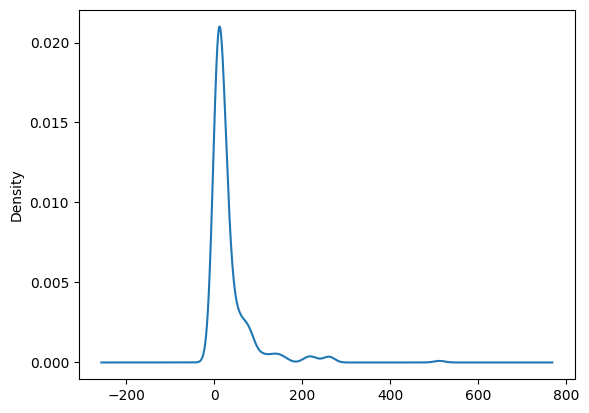

In [4]:
df['Fare'].plot(kind='kde')

The Fare data is not normally distributed.

> Why?

* Most passengers paid low fares
* Few passengers paid very high fares
* This creates a right-skewed distribution (long tail on the right side)

**This is important because:**

* Many statistical methods assume normal distribution
* But in real life, data is often skewed like this

# Sampling Process

Instead of using the full dataset, we:

* Randomly take 30 sample from the Fare column.
* Calculate the sample mean and sample SD
* Repeat this process 10 times

👉 This helps us understand:

How much the sample mean varies
How close it gets to the actual population mean

In [6]:
# sample size = 30 --> 10 times
samples=[]
stds=[]
for i in range(10):
    x= df['Fare'].dropna().sample(30).values
    stds.append(x.std())
    samples.append(x.tolist())

In [7]:
samples = np.array(samples)
samples

array([[  0.    ,  20.525 ,  69.55  ,   7.775 ,  78.85  ,  39.6875,
         90.    ,  30.    ,  10.5   ,  27.    ,   8.05  ,  10.5   ,
          7.225 ,  31.5   ,  20.575 ,   7.7958,   7.8542,  15.85  ,
        227.525 ,  23.    ,   8.6625,  16.    ,  19.9667,  39.6875,
         53.1   ,   8.05  ,  13.775 ,   7.7958,   7.25  ,  10.1708],
       [ 39.    ,  26.    , 164.8667,  75.25  ,  15.2458,   6.95  ,
         15.55  ,  79.2   ,  26.55  ,  12.475 , 211.5   ,  13.    ,
         75.2417,  13.    ,  29.7   ,   7.225 ,  20.25  ,  30.    ,
        211.5   ,  26.    ,   7.5792,  26.25  ,  26.    ,  13.5   ,
         10.5   , 133.65  ,  13.    ,  36.75  ,   7.8792,  13.5   ],
       [ 66.6   , 134.5   ,   6.975 ,   7.8958,  79.2   ,  56.9292,
          7.8542,  86.5   , 211.5   ,   7.225 ,  90.    ,  10.5   ,
        135.6333,   8.6542,  29.125 ,  83.1583,  53.1   ,  11.5   ,
         10.5   ,  29.125 , 221.7792,   7.7333,   7.8958,   9.825 ,
          7.8542,  15.0333, 135.6333,  52.    

In [8]:
samples.shape

(10, 30)

In [10]:
stds

[np.float64(42.722039635342),
 np.float64(57.2379953696478),
 np.float64(59.83890675451707),
 np.float64(63.19864352987517),
 np.float64(98.51334806609238),
 np.float64(91.35965604560326),
 np.float64(49.562228629845954),
 np.float64(58.89074527318692),
 np.float64(46.38821452814988),
 np.float64(30.956401357128957)]

In [9]:
# Xbar --> Sample mean of sampling distribution
sampling_mean=(samples.mean(axis=1))
sampling_mean


array([30.60736   , 46.23708667, 53.72277667, 37.07111   , 42.64236   ,
       38.28542   , 37.49972333, 41.58291667, 35.23166333, 23.70999667])

In [11]:
Sample_std= (np.array(stds)).mean()
Sample_std

np.float64(59.86681791893894)

In [12]:
Sample_std= np.mean(stds)
Sample_std

np.float64(59.86681791893894)

In [13]:
sampling_mean.mean()

np.float64(38.65904133333333)

# Confidence Interval Calculation

We use the **T-distribution** to calculate the confidence interval because:

* Population standard deviation is unknown
* Sample size is limited
  
What we calculate:
* Average of all Sample mean
* Average of all Sample standard deviation
* Margin of error

Using these, we estimate a 95% Confidence Interval

> This interval tells us: “There is a 95% chance that the true population mean lies within this range.”



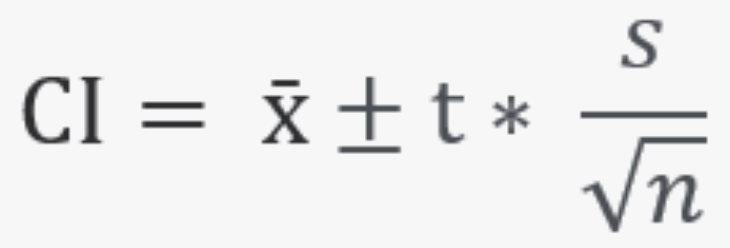

In Students T- procedure we use sample SD (s), Here we are creating 10 samples. Generally we calculate SD of all the samples and then do the Average of that. That Average SD will be used in formula.

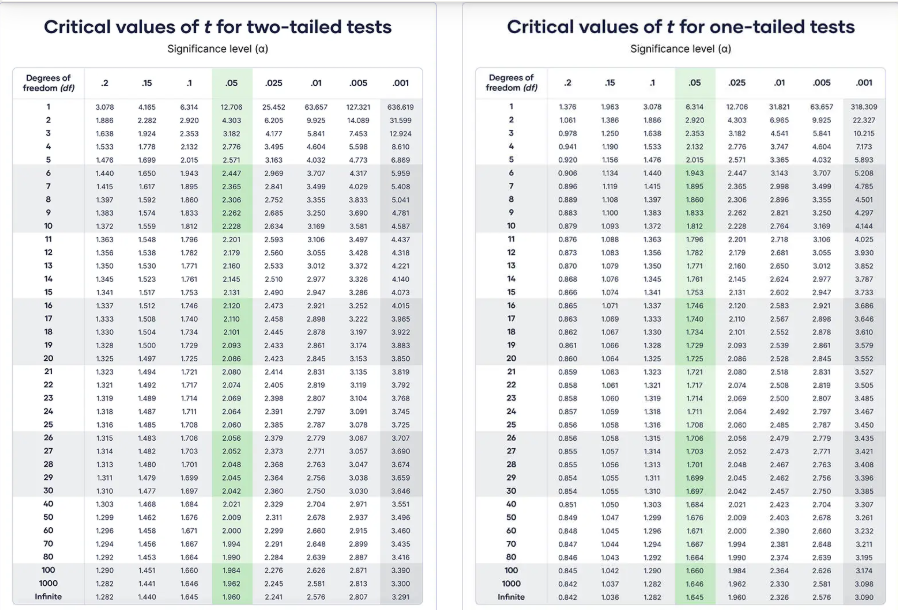

In T-table for 95 % Confidence level and at DF of 30 the t value is 2.042


In [14]:
lower_limit=sampling_mean.mean() - 2.042*(Sample_std/np.sqrt(30))
upper_limit=sampling_mean.mean() + 2.042*(Sample_std/np.sqrt(30))

In [15]:
print('The range is', lower_limit, '-', upper_limit)

The range is 16.339704560478165 - 60.97837810618849


In [16]:
df['Fare'].dropna().mean()

np.float64(33.295479281345564)

**Insight:**
*  The true mean lies inside your interval
* This means your sampling + calculation is correct and reliable

If we dec the confidence level ie at 50 % . At 50% confidence level the t-value is 0.683

In [17]:
lower_limit=sampling_mean.mean() - 0.683*(Sample_std/np.sqrt(30))
upper_limit=sampling_mean.mean() + 0.683*(Sample_std/np.sqrt(30))

In [18]:
print('The range is', lower_limit, '-', upper_limit)

The range is 31.193758759454738 - 46.12432390721192


Range decreased by we are less confident.

More confidence means more uncertainty coverage, hence a wider interval.

# Trade-off Between Accuracy & Confidence
* 95% CI → safer but less precise
* 50% CI → precise but risky
* here is always a trade-off between confidence and precision.

# Insight
Even with a sample, we can estimate the population mean, but the reliability depends on confidence level, sample size, and data variability.